# Level 2 Task 2 - Cuisine Combination

#### Objective
Identify the most common cuisine combinations in the dataset 
and check if certain combinations tend to have higher ratings.

Step 1 → Look at the Cuisines column

Step 2 → Count how many times each combination appears

Step 3 → Find top 10 most common combinations

Step 4 → Calculate average rating for each combination

Step 5 → Make a chart to visualize

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Restaurant Analysis.xlsx')
df.columns = df.columns.str.replace('ï»¿', '')

df = df.dropna(subset=['Cuisines'])

In [4]:
df['Cuisines'].head(10)

0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: Cuisines, dtype: object

### Counting Cuisine Combinations

We filter out single cuisines and keep only restaurants 
that serve more than one cuisine. Then we count how many 
times each combination appears to find the most common ones.

In [5]:
# Keep only rows that have more than one cuisine
combo_only = df[df['Cuisines'].str.contains(',')]

combo_counts = combo_only['Cuisines'].value_counts()
print(combo_counts.head(10))

Cuisines
North Indian, Chinese             511
North Indian, Mughlai             334
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
Bakery, Fast Food                 108
Chinese, North Indian             105
Ice Cream, Desserts                83
Name: count, dtype: int64


#### Observation

After filtering single cuisines, the most common combination 
is North Indian and Chinese with 511 restaurants. North Indian 
appears in 3 of the top 5 combinations which shows it is 
commonly paired with other cuisines. Bakery and Desserts is 
the most common non-Indian combination with 170 restaurants.

### Average Rating per Cuisine Combination

In [9]:
# Calculate average rating for each cuisine combination
combo_ratings = combo_only.groupby('Cuisines')['Aggregate rating'].mean()

# Sort from highest to lowest rating
combo_ratings = combo_ratings.sort_values(ascending=False)

# Show top 10 highest rated combinations
print(combo_ratings.head(10))

Cuisines
Italian, Deli               4.9
Continental, Indian         4.9
Hawaiian, Seafood           4.9
American, Burger, Grill     4.9
American, Coffee and Tea    4.9
European, Contemporary      4.9
Sunda, Indonesian           4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
Mughlai, Lucknowi           4.9
Name: Aggregate rating, dtype: float64


#### Note 
Checking Restaurant Count Behind Each Combination

The top rated combinations all show 4.9 rating which looks 
suspicious. We check how many restaurants are behind each 
combination to see if the average rating is reliable.

In [10]:
# Check count of restaurants for each combination
combo_count_check = combo_only.groupby('Cuisines')['Aggregate rating'].count()
combo_count_check = combo_count_check.sort_values(ascending=False)

# Show combinations with highest ratings and their restaurant count
top_rated = combo_ratings.head(10)
for combo in top_rated.index:
    count = combo_count_check[combo]
    rating = combo_ratings[combo]
    print(f"{combo}: {count} restaurants, avg rating {rating}")

Italian, Deli: 1 restaurants, avg rating 4.9
Continental, Indian: 1 restaurants, avg rating 4.9
Hawaiian, Seafood: 1 restaurants, avg rating 4.9
American, Burger, Grill: 1 restaurants, avg rating 4.9
American, Coffee and Tea: 1 restaurants, avg rating 4.9
European, Contemporary: 1 restaurants, avg rating 4.9
Sunda, Indonesian: 3 restaurants, avg rating 4.9
European, German: 1 restaurants, avg rating 4.9
BBQ, Breakfast, Southern: 1 restaurants, avg rating 4.9
Mughlai, Lucknowi: 1 restaurants, avg rating 4.9


#### Note

The above results show many combinations with 4.9 rating but 
most of them have only 1 restaurant. A single restaurant's 
rating is not reliable enough to conclude. So we filter 
combinations with atleast 10 restaurants for a fair comparison.

### Filtering Reliable Combinations

Since most top rated combinations have only 1 restaurant, 
their average rating is not reliable. We now filter and 
consider only combinations that have atleast 10 restaurants 
to get a fair and meaningful comparison.

In [11]:
# Calculate count and average rating together
combo_summary = combo_only.groupby('Cuisines')['Aggregate rating'].agg(['count', 'mean'])

# Filter only combinations with at least 10 restaurants
combo_summary = combo_summary[combo_summary['count'] >= 10]

# Sort by average rating
combo_summary = combo_summary.sort_values('mean', ascending=False)

print(combo_summary.head(10))

                                             count      mean
Cuisines                                                    
Cafe, Continental, Italian                      10  4.080000
American, Burger                                13  4.076923
Japanese, Sushi                                 18  4.044444
Pizza, Italian                                  19  3.668421
Italian, Pizza                                  24  3.637500
North Indian, Chinese, Continental, Italian     12  3.608333
Cafe, Italian                                   12  3.583333
Cafe, Continental                               12  3.558333
Continental, North Indian, Chinese              10  3.540000
Continental, Italian                            13  3.538462


#### Observation

After filtering combinations with atleast 10 restaurants, 
Cafe+Continental+Italian and American+Burger have the highest 
average rating of 4.08. Japanese and Sushi combination is 
third with 4.04. Interestingly Pizza+Italian and Italian+Pizza 
appear as separate combinations but are essentially the same, 
which indicates inconsistency in how cuisine data was entered.

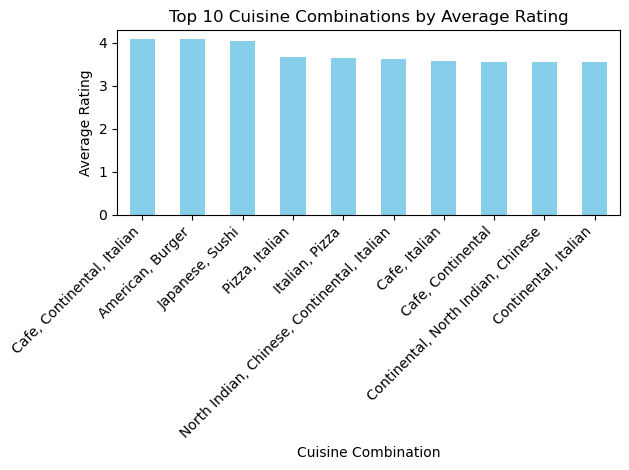

In [12]:
top10_combos = combo_summary.head(10)

top10_combos['mean'].plot(kind='bar', color='skyblue')
plt.title('Top 10 Cuisine Combinations by Average Rating')
plt.xlabel('Cuisine Combination')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observation

The bar chart shows that the top 3 highest rated combinations 
are Cafe+Continental+Italian, American+Burger and Japanese+Sushi 
all above 4.0 rating. All top 10 combinations have ratings 
between 3.5 and 4.1. Pizza+Italian and Italian+Pizza appear as two separate bars which shows 
inconsistency in data entry.